In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

swedish_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/SWEDISH/results/output_tables/MSA_SWEDISH/pruned_attribution_MSA_SWEDISH_SBS_abs_mutations.csv',
                  index_col=0)

swed_metadata = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/data_from_other_papers/Swedish_data/supp_tables/Supplementary_Table_01.csv',index_col=1,
                           skiprows=[0,1])

# swedish_meta = swed_metadata.loc[:,['Sex','Age at diagnosis','Tumour Site']]
swed_metadata.columns = swed_metadata.columns.str.replace(' ','_')

swed_metadata = swed_metadata.loc[swedish_msa.index]

swed_metadata['age'] = swed_metadata.loc[:,'Age_at_diagnosis']
swed_metadata['sex'] = swed_metadata.loc[:,'Sex']
swed_metadata['subsite'] = swed_metadata.loc[:,'Tumour_Site']

swed_metadata['purity'] = swed_metadata.loc[:,'Tumour_Cell_Content_Pathology']/100

swed_metadata['SBS_D'] = (swedish_msa.loc[:,'SBS288E'] > 0).astype(int)

In [ ]:
# Swedish logistic regression

In [2]:
from scipy import stats 
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm

import statsmodels.formula.api as smf

In [3]:
swed_metadata['age_diag'] = swed_metadata.loc[:,'Age_at_diagnosis']
swed_metadata['sex'] = swed_metadata.loc[:,'Sex']
swed_metadata['tumorsite_group'] = swed_metadata.loc[:,'Tumour_Site']


In [5]:
swed_metadata['tumor_subsite'] = swed_metadata.loc[:,'tumorsite_group']

swed_metadata['tumor_subsite'] = swed_metadata['tumor_subsite'].str.replace('Left Colon','Proximal colon').str.replace('Right Colon','Distal colon')


In [7]:
swed_metadata['Grade'] = swed_metadata.loc[:,'Tumour_Grade']

In [11]:
swed_metadata['stage'] = swed_metadata.loc[:,'Tumour_Stage'].str.split(' ').str[-1]
swed_metadata['Stage'] = swed_metadata['stage'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').astype(float)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86267/2601125790.py:109: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(reset_labels)


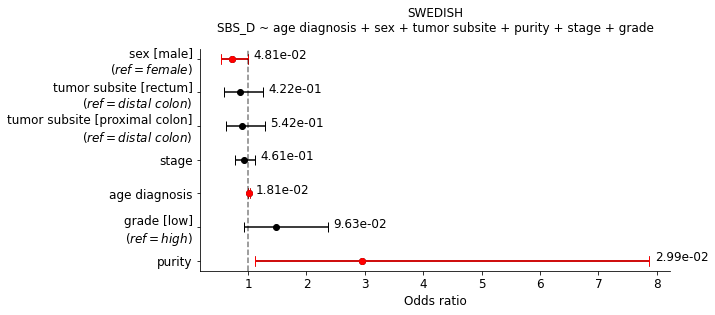

In [12]:
# add country 

# age, sex, tumorsite group, country, purity
# standard covariates
# nothing associated

import numpy as np

variable = 'None'

model = smf.glm(formula = 'SBS_D' + " ~ age_diag + sex + tumor_subsite + purity + Stage + Grade", 
            data =swed_metadata, family = sm.families.Binomial())
            #family = sm.families.Binomial())

result = model.fit()
result_table = result.summary2().tables[1]
result_table=result_table.drop('Intercept')
result_table = result_table.reset_index()


result_table['Odds_ratio'] = np.exp(result_table.loc[:,'Coef.'])
result_table = result_table.sort_values('Coef.',ascending=False)


fig,ax = plt.subplots(figsize=(10,4.5))

lower = np.exp(result_table['[0.025'])     # lower bound of CI (odds ratio)
upper = np.exp(result_table['0.975]'])     # upper bound of CI (odds ratio)
center = result_table['Odds_ratio']        # center point (odds ratio)

# Calculate asymmetric error bars
xerr_lower = center - lower
xerr_upper = upper - center

# Combine for plt.errorbar (2 x N shape)
xerr = np.array([xerr_lower, xerr_upper])
plt.errorbar(result_table['Odds_ratio'], result_table.loc[:,'index'],
             xerr=xerr, fmt="o",capsize=5,color='black')


# significant results 
result_table_ = result_table[result_table.loc[:,'P>|z|'] < .05]

lower = np.exp(result_table_['[0.025'])     # lower bound of CI (odds ratio)
upper = np.exp(result_table_['0.975]'])     # upper bound of CI (odds ratio)
center = result_table_['Odds_ratio']        # center point (odds ratio)

# Calculate asymmetric error bars
xerr_lower = center - lower
xerr_upper = upper - center

# Combine for plt.errorbar (2 x N shape)
xerr2 = np.array([xerr_lower, xerr_upper])

plt.errorbar(result_table_['Odds_ratio'], result_table_.loc[:,'index'],
             xerr=xerr2, fmt="o",color='red',capsize=5)

# plt.errorbar(result_table_['Odds_ratio'], result_table_.loc[:,'index'],
#              xerr=result_table_.loc[:,'Std.Err.']*2, fmt="o",color='red',capsize=5)





plt.xlabel('Odds ratio')
plt.axvline(1,color='black',alpha=.5,linestyle='--')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('SWEDISH\n' + model.formula.replace('_',' ').replace('SBS D','SBS_D').replace('diag','diagnosis').replace(variable,r"$\bf{" + variable  + "}$" ).replace('Stage','stage').replace('Grade','grade'),fontsize=12,
         y=1.05)

result_table.index = result_table.loc[:,'index']
for i, txt in enumerate(result_table.loc[:,'P>|z|']):
    ax.annotate('{:0.2e}'.format(txt),(np.exp(result_table.loc[:,'0.975]'])[i]+ .1,
                      result_table.loc[:,'index'][i]),fontsize=12)

# result_table.index = result_table.loc[:,'index']
# for i, txt in enumerate(result_table.loc[:,'P>|z|']):
#     ax.annotate('{:0.2e}'.format(txt),((result_table.loc[:,'Std.Err.']*2)[i] + result_table.loc[:,'Odds_ratio'][i] + .1,#result_table.loc[:,'0.975]'][i],
#                       result_table.loc[:,'index'][i]),fontsize=12)

    
# plt.xlim(-1,5)
reset_labels = []
reset_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    if variable in text:
        label = label.set_color('blue')
    text = text.replace('[T.',' [').replace('_',' ').replace(' diag',' diagnosis').replace('Stage','stage').lower()
    if 'subsite' in text:
        text = text.replace(']',']\n$\mathit{(ref=distal\ colon)}$')
    
    if 'grade' in text:
        text = text.lower().replace(']',']\n$\mathit{(ref=high)}$').replace('low grade','low')
        
    if 'sex' in text:
        text = text.replace(']',']\n$\mathit{(ref=female)}$')
    reset_labels.append(text)    
    


ax.set_yticklabels(reset_labels)    

plt.tight_layout()

# plt.savefig('reviewer_plots/associations_Swedish/ALL.png',
#            dpi=300)